<a href="https://colab.research.google.com/github/Vieiraligia/Data-Science-and-Analytics/blob/main/MVP%20Analise%20de%20Dados%20e%20Boas%20Praticas/MVP_AnalisedeDadoseBoasPraticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Análise de Dados e Boas Práticas

**Autora:** Ligia R. Vieira  

**Matrícula:** 1200158

**Data:** Março/2026


**Dataset:** [ Students Performance](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?resource=download)

# Definição do Problema

O objetivo deste projeto é analisar os fatores que influenciam o desempenho acadêmico de estudantes nos exames, tendo como base de referência o Dataset <i>**Students Performance in Exams**</i>.

O dataset é composto por informações demográficas, sociais e educacionais dos estudantes, além de notas em matemática, leitura e escrita.

A análise busca compreender padrões e relações entre as variáveis, com o objetivo de identificar quais fatores podem impactar de forma positiva ou negativa o desempenho dos alunos.

Para isso, a composição da análise será realizada por meio de estatísticas descritivas, visualizações e técnicas de pré-processamento de dados.
<br><br>
## Hipóteses do Problema

1. Estudantes que realizaram curso preparatório tendem a apresentar melhores notas.
2. Existe diferença de desempenho entre estudantes do sexo masculino e feminino.
3. Fatores demográficos e sociais podem evidenciar algum tipo de desigualdade no desempenho acadêmico.
4. Existe alguma correlação entre as notas de leitura e escrita.
5. As notas de matemática apresentam maior variabilidade, indicando maior dispersão dos resultados em relação às disciplinas de leitura e escrita.
<br>

## Tipo do Problema

Este é um problema de aprendizado supervisionado de regressão, porque envolve possível previsão de valores numéricos relacionados ao desempenho dos estudantes, como as notas em matemática, leitura e escrita.
<br><br>
## Seleção de Dados

O Dataset escolhido foi obtido no repositório Kaggle, sendo um conjunto de dados público e previamente estruturado.
Dessa forma, o foco do trabalho concentra-se na análise exploratória e no pré-processamento dos dados.
<br><br>
## Atributos do Dataset


O conjunto de dados é composto por variáveis categóricas relacionadas a informações demográficas e socioeconômicas, gênero, grupo étnico, tipo de alimentação escolar, escolaridade dos pais e participação em curso preparatório. Além disso, contém variáveis numéricas correspondentes às notas obtidas nas disciplinas de matemática, leitura e escrita. O conjunto reúne 8 atributos.

Atributos categórico:
- gender
- race/ethnicity
- parental level of education
- lunch
- test preparation course

Atributos numérico:
- math score
- reading score
- writing score



## Importação das Bibliotecas Necessárias e Carga de Dados
Para a realização do trabalho, foram utilizadas bibliotecas mais utilizadas na área de Ciência de Dados como: Pandas, NumPy, Matplotlib, Seaborn e Scikit-learn.

In [9]:
# Imports necessários

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML

# teste
from sklearn.model_selection import train_test_split



In [10]:
# acessando o dataset pelo meu github (raw)
url = "https://raw.githubusercontent.com/Vieiraligia/Data-Science-and-Analytics/main/MVP%20Analise%20de%20Dados%20e%20Boas%20Praticas/StudentsPerformance.csv"


df = pd.read_csv(url)



In [11]:
display(HTML("<h3 style='text-align:center;'>Primeiras 15 linhas do Dataset</h3>"))
df.head(15)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


# Análise de Dados - EDA


A realização da Análise de Dados Exploratória (EDA) tem como objetivo compreender as informações disponíveis no Dataset<b> *Students Performance in Exams*</b>, aplicando:

As análises descritivas e estatísticas:
- Quantidade de atributos e instâncias presentes no dataset;
- Identificação dos tipos de dados de cada atributo;
- Análise das primeiras linhas do conjunto de dados, buscando identificar padrões iniciais ou possíveis inconsistências;
- Verificação da existência de valores nulos, outliers ou dados inconsistentes;
- Cálculo de estatísticas descritivas dos atributos numéricos, como mínimo, máximo, média, mediana, desvio-padrão, quartis e moda.
<br>

A visualização de dados:

- Análise da distribuição dos atributos por meio de histogramas e gráficos de contagem;
- Avaliação da relação entre variáveis por meio de boxplots;
- Análise da correlação entre variáveis numéricas por meio de matriz de correlação.

Além do objetivo de compreender os dados, a análise estatística e a visualização são orientadas para a validação das hipóteses levantadas.

### Total e Tipo das Instâncias


Como mencionado anteriormente, esse conjunto de dados é composto por 8 atributos de variáveis categóricas, representadas pelo tipo <b><i>object </b></i> e variáveis numéricas, representadas pelo tipo <b><i>int64</b></i>. Observa-se que não há valores faltantes, pois todos os atributos retornam 1000 registros para cada atributo.



In [21]:
print("Total de instâncias:", len(df))
print("Total de atributos:", len(df.columns))
print("Tipos de dados: \n")

print(df.info())


Total de instâncias: 1000
Total de atributos: 8
Tipos de dados: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


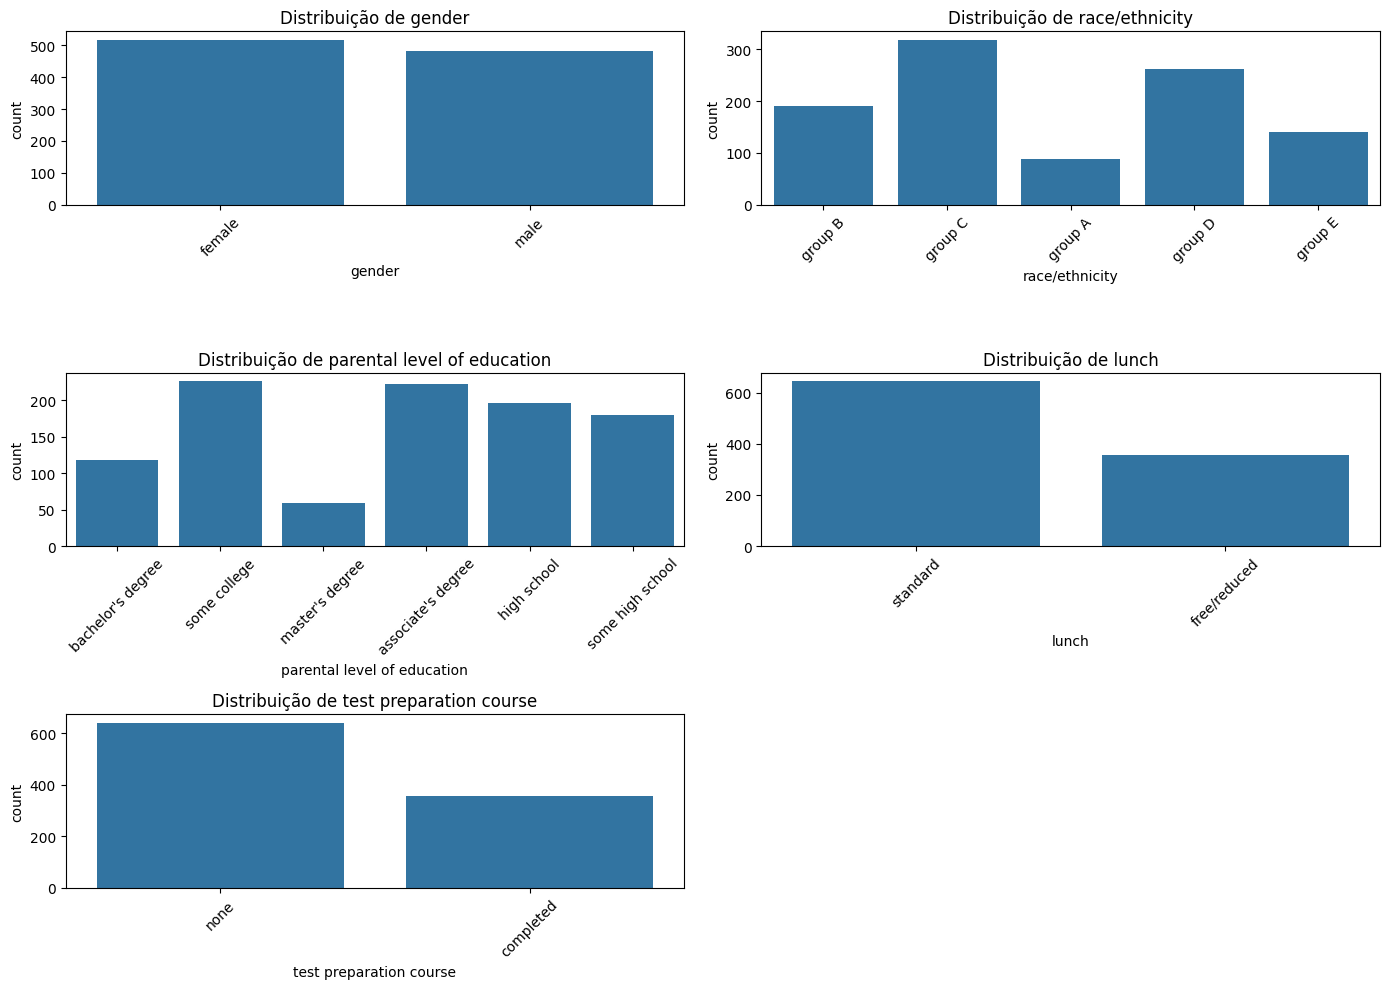

In [22]:

colunas_categoricas = df.select_dtypes(include="object").columns

plt.figure(figsize=(14,10))

for i, col in enumerate(colunas_categoricas, 1):
    plt.subplot(3,2,i)
    sns.countplot(data=df, x=col)
    plt.title(f"Distribuição de {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

A análise da distribuição das variáveis categóricas indica que o Dataset não apresenta um balanceamento uniforme entre todas as categorias. Pois algumas apresentam maior frequência de observações, enquanto outras possuem menor representação.

## Estatísticas Descritivas

In [27]:
# melhor estilizacao

display(HTML("<h3 style='text-align:center;'>Estatísticas Descritivas</h3>"))
descriptive_statistics = pd.concat([
    df.describe()[['math score',
                   'reading score',
                   'writing score']].round(2).T,

    df[['math score',
        'reading score',
        'writing score']].mode().round(2).T
],
axis=1).rename(columns={
    'count': 'Contagem',
    'std': 'Desvio Padrão',
    'mean': 'Média',
    'min': 'Mínimo',
    'max': 'Máximo',
    '25%': '1º Quartil',
    '50%': 'Mediana',
    '75%': '3º Quartil',
    0: 'Moda'
})
descriptive_statistics

,Contagem,Média,Desvio Padrão,Mínimo,1º Quartil,Mediana,3º Quartil,Máximo,Moda
math score,1000.0,66.09,15.16,0.0,57.00,66.0,77.0,100.0,65
reading score,1000.0,69.17,14.60,17.0,59.00,70.0,79.0,100.0,72
writing score,1000.0,68.05,15.20,10.0,57.75,69.0,79.0,100.0,74


Dentro da Estatística Descritiva, existem medidas que auxiliam na interpretação e no resumo dos dados. Entre essas medidas, destacam-se as de tendência central e de dispersão, que foram aplicadas às notas obtidas nas disciplinas de matemática, leitura e escrita.

Ao analisar as médias, observa-se que os estudantes apresentam desempenho médio de aproximadamente 66,09 em matemática, 69,17 em leitura e 68,05 em escrita. Em comparação com matemática, as disciplinas de leitura e escrita apresentam desempenho médio discretamente superior.

A análise do desvio padrão indica uma variabilidade moderada nas notas. Isso sugere que o desempenho dos estudantes apresenta certa dispersão em relação à média, evidenciando diferenças no desempenho entre os alunos.

A análise dos valores mínimos e máximos indica uma amplitude nas notas. Em matemática há registros que variam de 0 a 100.0 que evidencia desempenhos tanto no limite mínimo quanto no máximo da escala. Nas disciplinas de leitura e escrita observa-se comportamento semelhante, porém com valores mínimos levemente superiores.

A análise dos quartis permite identificar a faixa em que se concentra a maior parte das observações. Em matemática, 50% das notas estão aproximadamente entre 57 e 77 pontos. De maneira semelhante, nas disciplinas de leitura e escrita, a maior parte das notas também se encontra em intervalos próximos dessa faixa, com isso, o desempenho predominante dos estudantes encontra-se em nível intermediário.


## Visualização

### Histograma e KDE

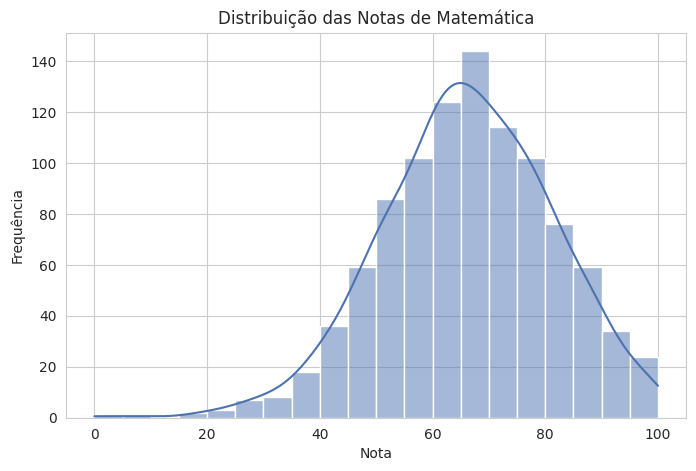

In [56]:
# distribuicao de nota e densidade mat.


sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

sns.histplot(df["math score"], bins=20, kde=True, color="#4C72B0")

plt.title("Distribuição das Notas de Matemática")
plt.xlabel("Nota")
plt.ylabel("Frequência")

plt.show()

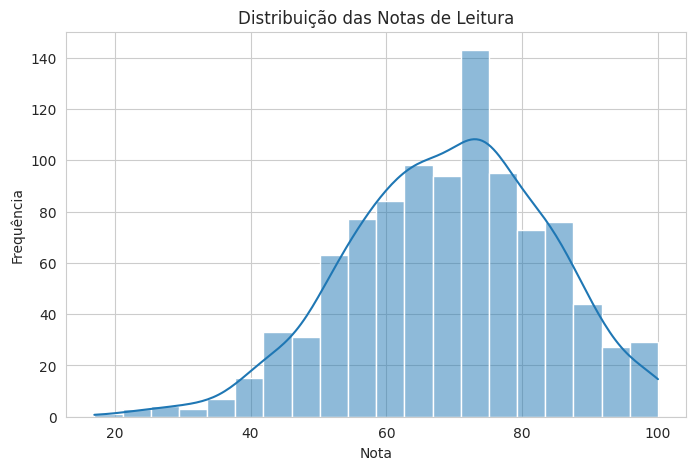

In [55]:
# distribuicao de nota e densidade leit.

plt.figure(figsize=(8,5))

sns.histplot(df["reading score"], bins=20, kde=True)

plt.title("Distribuição das Notas de Leitura")
plt.xlabel("Nota")
plt.ylabel("Frequência")

plt.show()

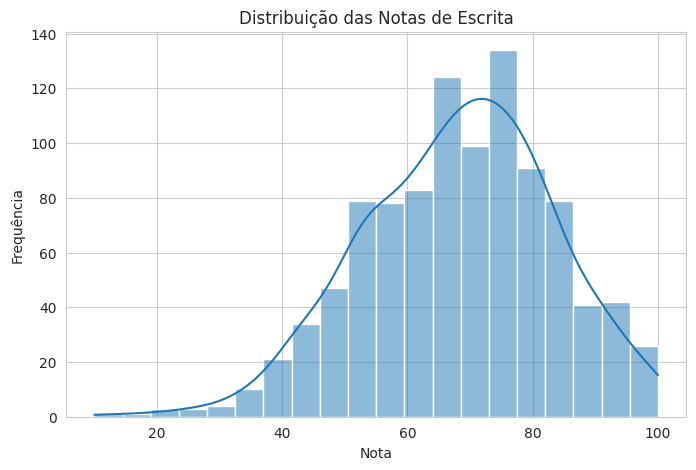

In [44]:
# distribuicao de nota e densidade escr.

plt.figure(figsize=(8,5))

sns.histplot(df["writing score"], bins=20, kde=True)

plt.title("Distribuição das Notas de Escrita")
plt.xlabel("Nota")
plt.ylabel("Frequência")

plt.show()

As distribuições das notas nas disciplinas parecem apresentar formato semelhante, onde a maior frequência de observações se concentra em torno das notas centrais, entre 60 e 80 pontos.

### Boxplot

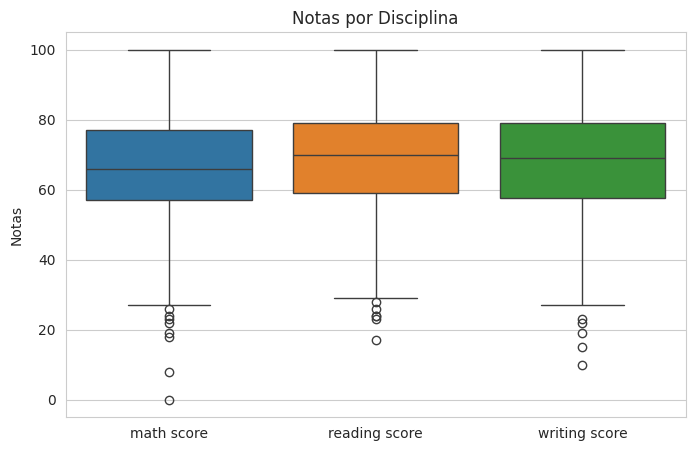

In [54]:
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

sns.boxplot(data=df[[
    "math score",
    "reading score",
    "writing score"
]])

plt.title("Notas por Disciplina")
plt.ylabel("Notas")

plt.show()

Ainda no contexto de análise de distribuição e da dispersão dos dados, o gráfico do tipo Boxplot tem uma função complementar de análise.

As percepções visuais identificam uma certa dispersão na disciplina de matemática, sugerindo uma possível presença de outlier ou, de fato, um valor real referente às notas de estudantes.




### Matriz de Correlação

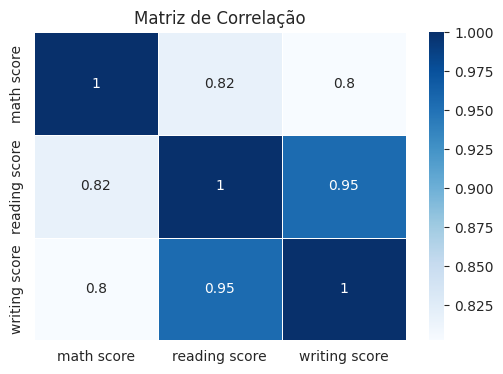

In [66]:

corr = df[["math score","reading score","writing score"]].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    linewidths=0.5
)

plt.title("Matriz de Correlação")
plt.show()

A análise do grau de relação linear entre as notas das disciplinas aponta um indício inicial para a validação de uma das hipóteses.

Observa-se uma forte correlação positiva entre leitura e escrita, ou seja, estudantes com melhor desempenho em leitura tendem também a apresentar melhores resultados em escrita. Por outro lado, as correlações envolvendo a disciplina de matemática mostram uma relação menos intensa com as demais.

### Verificação de Valores Nulos e Duplicados

In [78]:
display(HTML("<h3 style='text-align:center;'>Verificação dos Dados</h3>"))

display(HTML("<h4>Valores Nulos</h4>"))
display(df.isna().sum())

display(HTML("<h4>Registros Duplicados:</h4>"))
display(df.duplicated().sum())

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


np.int64(0)

A verificação realizada indica que não há valores ausentes em nenhum dos atributos e também não foram identificadas instâncias duplicadas no conjunto de dados.

Dessa forma, os dados apresentam boa qualidade inicial para as etapas de análise exploratória e pré-processamento.

## Exploração Adicional dos Dados

Seção adicional voltada à visualização, ao aprofundamento da análise e à exploração do conjunto de dados, na busca de padrões e relações entre as diferentes variáveis.

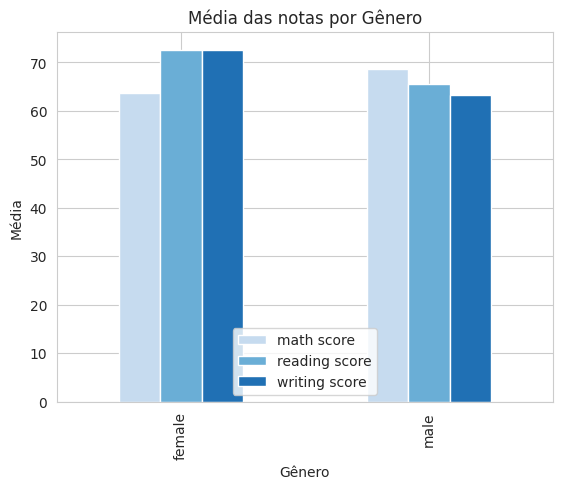

In [84]:
# média de nota por sexo
 # ajuda na hipotese 2


cores = sns.color_palette("Blues", 3)

df.groupby('gender')[['math score','reading score','writing score']]\
  .mean()\
  .plot(kind='bar', color=cores)

plt.title('Média das notas por Gênero')
plt.ylabel('Média')
plt.xlabel('Gênero')

plt.show()

<Axes: xlabel='race/ethnicity', ylabel='Nota Média'>

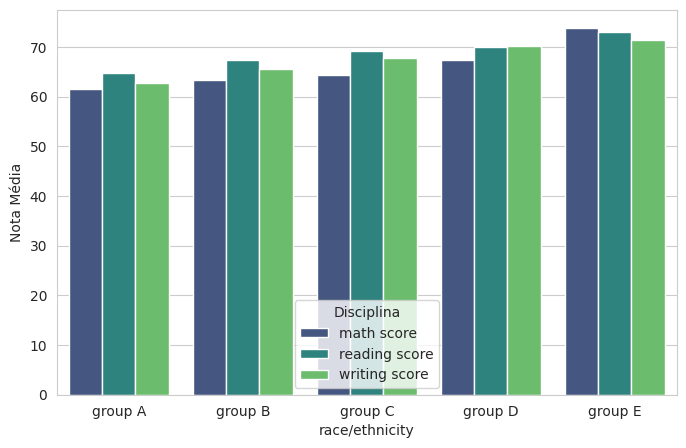

In [86]:
# de fato a raça/etnia interfere na média das notas?

media_raca = df.groupby('race/ethnicity')[[
    'math score',
    'reading score',
    'writing score'
]].mean().reset_index()

media_raca_melt = media_raca.melt(
    id_vars='race/ethnicity',
    var_name='Disciplina',
    value_name='Nota Média'
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=media_raca_melt,
    x='race/ethnicity',
    y='Nota Média',
    hue='Disciplina',
    palette='viridis'
)

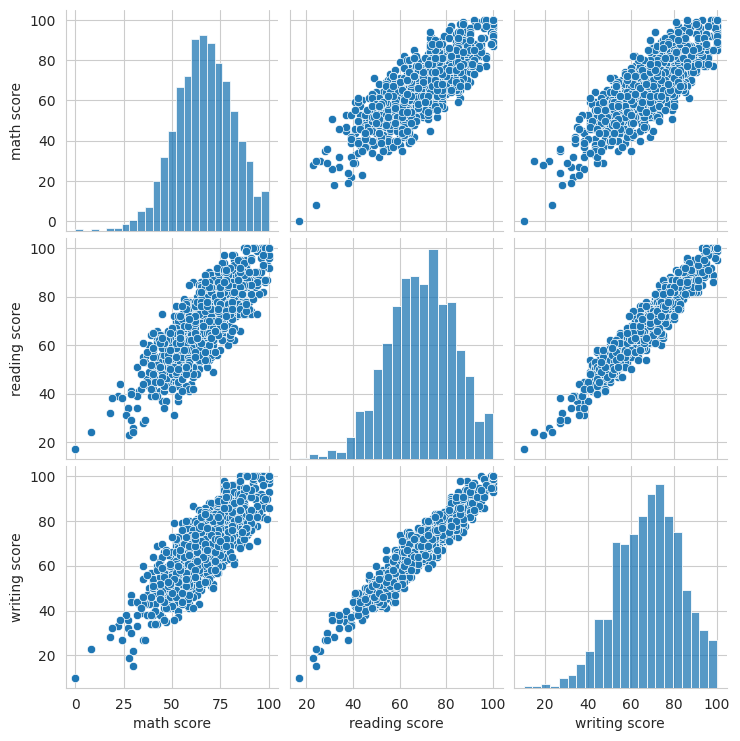

In [51]:
sns.pairplot(df[[
    "math score",
    "reading score",
    "writing score"
]])

## Visualizações

Em continuidade à análise dos dados, são avaliadas as distribuições das variáveis, a concentração dos valores em determinadas faixas, bem como a possível presença de dispersão e de outliers.

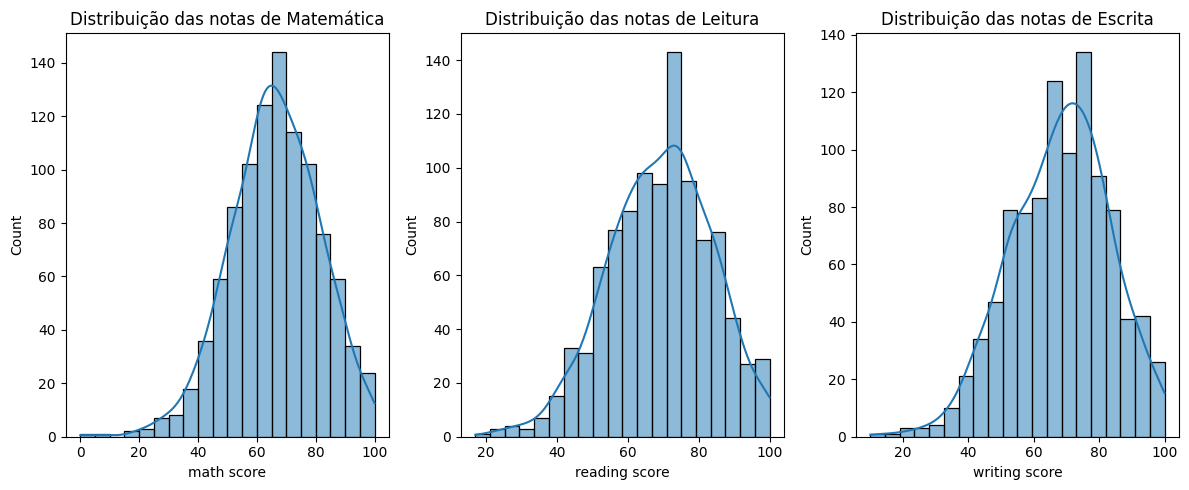

In [31]:
# Dist. por notas
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
sns.histplot(df['math score'], bins=20, kde=True)
plt.title('Distribuição das notas de Matemática')

plt.subplot(1,3,2)
sns.histplot(df['reading score'], bins=20, kde=True)
plt.title('Distribuição das notas de Leitura')

plt.subplot(1,3,3)
sns.histplot(df['writing score'], bins=20, kde=True)
plt.title('Distribuição das notas de Escrita')

plt.tight_layout()
plt.show()

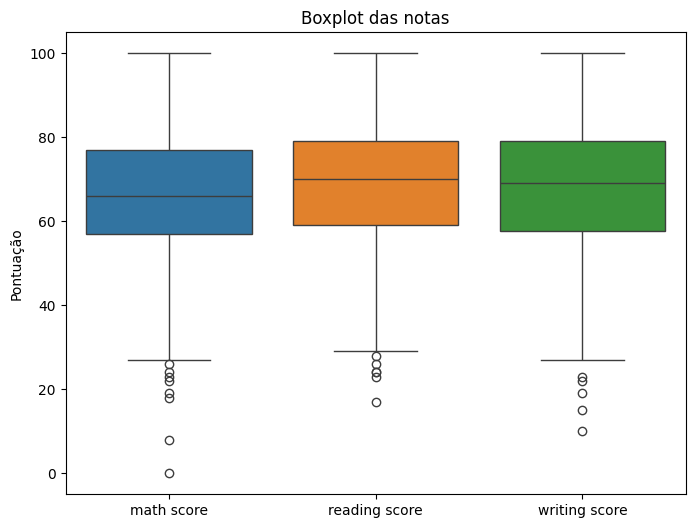

In [32]:
# Vendo possíveis outliers

plt.figure(figsize=(8,6))

sns.boxplot(data=df[['math score','reading score','writing score']])

plt.title('Boxplot das notas')
plt.ylabel('Pontuação')
plt.show()

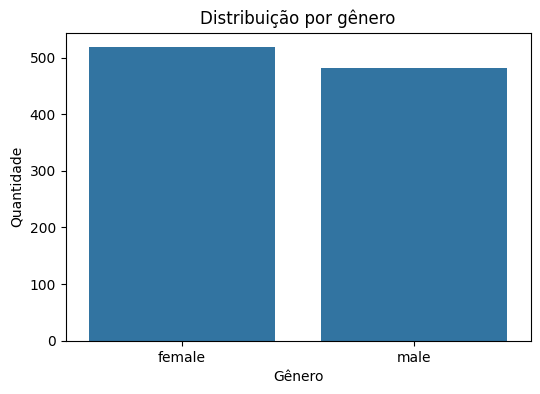

In [9]:
# Distr. por gênero

plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=df)

plt.title('Distribuição por gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.show()

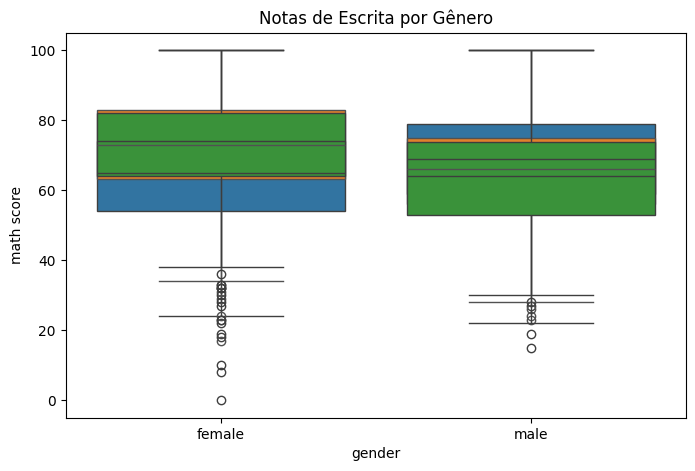

In [10]:
# Compar. de notas por gênero

plt.figure(figsize=(8,5))

sns.boxplot(x='gender', y='math score', data=df)
sns.boxplot(x='gender', y='reading score', data=df)
sns.boxplot(x='gender', y='writing score', data=df)

plt.title('Notas de Matemática por Gênero')
plt.title('Notas de Leitura por Gênero')
plt.title('Notas de Escrita por Gênero')
plt.show()


Text(0.5, 1.0, 'Impacto do curso preparatório na nota de matemática')

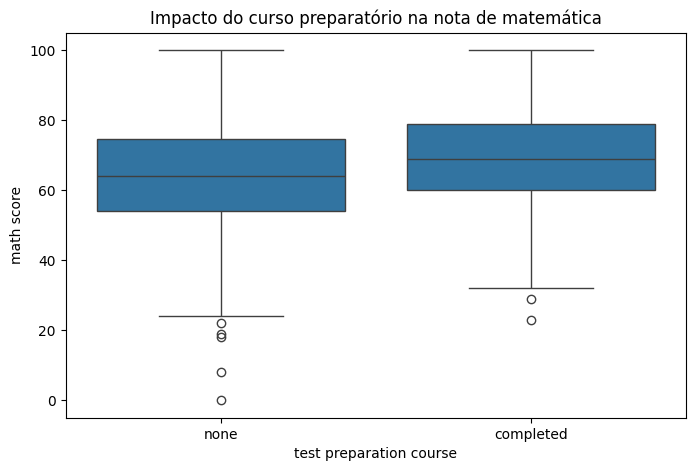

In [12]:
#Tem algum impacto quem fez curso prep.?

plt.figure(figsize=(8,5))

sns.boxplot(x='test preparation course', y='math score', data=df)

plt.title('Impacto do curso preparatório na nota de matemática')

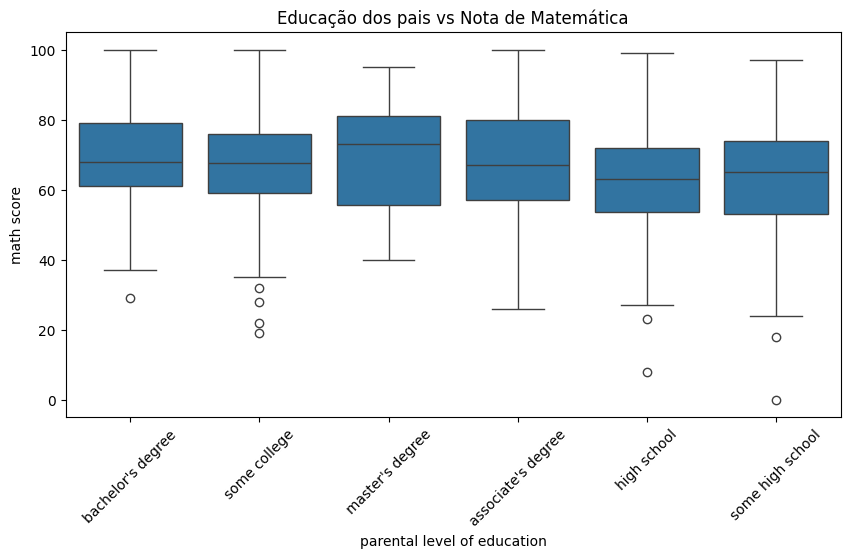

In [ ]:
# Educação dos pais interfere?
plt.figure(figsize=(10,5))

sns.boxplot(x='parental level of education', y='math score', data=df)

plt.xticks(rotation=45)

plt.title('Educação dos pais vs Nota de Matemática')
plt.show()

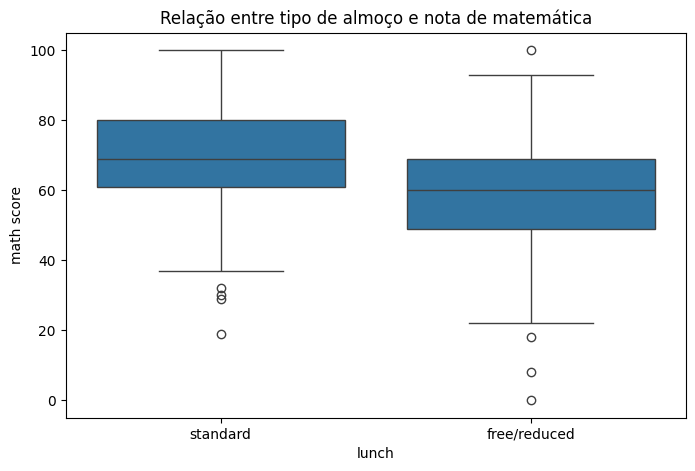

In [ ]:
#Dierença socioeconômica interfere?

plt.figure(figsize=(8,5))

sns.boxplot(x='lunch', y='math score', data=df)

plt.title('Relação entre tipo de almoço e nota de matemática')
plt.show()

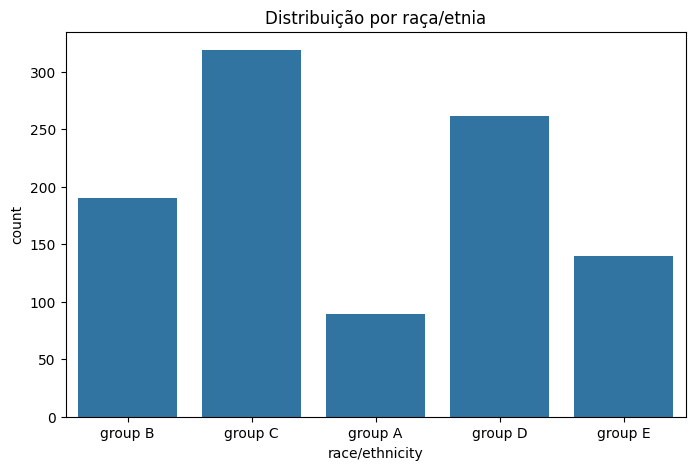

In [ ]:
# Raça e etnia interfere?

plt.figure(figsize=(8,5))

sns.countplot(x='race/ethnicity', data=df)

plt.title('Distribuição por raça/etnia')
plt.show()

A análise exploratória dos dados, realizada por meio de diferentes visualizações, permite a melhor compreensão das características dos dados. De forma a complementar as estatistícas descritivas realizadas anteriormente. Além disso, essa etapa fornece insights importantes para as fases posteriores do processo de preparação e tratamento dos dados.

Como conclusão da análise exploratória, observa-se a necessidade de algumas necessidades relacionadas ao pré-processamento dos dados:

* Codificação de variáveis categóricas;
* Verificação e possível tratamento de outliers (existe valores extremos);
* Padronização das variáveis numéricas;
* Criação de novas variáveis representativas;
* Eventual discretização de desempenhos;
* Análise do balanceamento das categorias.


#Pré-Processamento de Dados

O Pré-Processamento de Dados tem como objetivo realizar as operações de limpeza de dados, tratamento e preparação dos dados. Essa etapa é essencial para o desenvolvimento de modelos de aprendizado supervisionado, especialmente em problemas de regressão, nos quais o objetivo é prever valores numéricos, a partir de um conjunto de variáveis explicativas.

Em Análise de Dados, foi realizada a verificação da presença de valores faltantes e de registros duplicados, e esse conjunto de dados não apresenta valores ausentes nem ocorrências de duplicidade. Além disso, as notas das disciplinas já se encontram padronizadas em uma escala de 0 a 100.0, o que torna dispensável a aplicação de técnicas de normalização ou transformação de escala.

Inicialmente, será realizada a transformação das variáveis categóricas em representações numéricas, visto que os algoritmos de regressão trabalham exclusivamente com dados quantitativos. Para as variáveis categóricas binárias, como 'gender' e 'test preparation course', será aplicada a codificação binária. Já para as variáveis categóricas com múltiplas categorias, como 'race/ethnicity', 'lunch' e 'parental level of education', será empregada a técnica de One-Hot Encoding, permitindo representar cada categoria por meio de variáveis indicadoras.

Posteriormente, será realizada a etapa de engenharia de atributos, onde novas variáveis derivadas poderão ser criadas a partir das informações originais do Dataset. Entre essas possíveis variáveis, destacam-se métricas agregadas das notas, como médias entre disciplinas e diferenças entre desempenhos específicos, com o objetivo de enriquecer o conjunto de atributos disponíveis para análise e validação das hipoteses.

Após a aplicação dessas transformações, o conjunto de dados estará adequadamente estruturado para as etapas subsequentes de análise e aplicação de modelos de regressão.


In [ ]:
# valores faltantes zerados
print("Valores nulos por coluna:")
print(df.isnull().sum())


# sem registros duplicados
print("Número de registros duplicados:")
print(df.duplicated().sum())

Valores nulos por coluna:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64
Número de registros duplicados:
0


Confirmação de ausência de valores faltantes e dados duplicados.

## Variáveis Categóricas Binárias e One-Hot Encoding

In [34]:
# codificacao de gender e course
# melhorar estilizacao


def estilo_df(df, titulo):
    display(HTML(f"""
        <h3 style='text-align:center; margin-bottom:15px;'>
             {titulo}
        </h3>
    """))

    display(
        df.head()
        .style
        .set_properties(**{
            "background-color": "#f9f9f9",
            "color": "#333",
            "border-color": "#ccc"
        })
        .set_table_styles([
            {"selector": "th",
             "props": [("background-color", "#4CAF50"),
                       ("color", "white"),
                       ("font-weight", "bold"),
                       ("text-align", "center")]},
            {"selector": "td",
             "props": [("text-align", "center")]}
        ])
        .highlight_max(axis=0, color="#c8e6c9")
    )

estilo_df(df, "Dados antes do pré-processamento")

display(HTML("<br><br><br>"))

df["gender"] = df["gender"].map({
    "female": 0,
    "male": 1
})

df["test preparation course"] = df["test preparation course"].map({
    "none": 0,
    "completed": 1
})

estilo_df(df, "Dados após o pré-processamento")


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,group B,bachelor's degree,standard,0,72,72,74
1,0,group C,some college,standard,1,69,90,88
2,0,group B,master's degree,standard,0,90,95,93
3,1,group A,associate's degree,free/reduced,0,47,57,44
4,1,group C,some college,standard,0,76,78,75


In [35]:
# codificacao de race, lunch e parental educ.
# padronizar estilizacao

def estilo_df(df, titulo):
    display(HTML(f"""
        <h3 style='text-align:center; margin-bottom:15px;'>
             {titulo}
        </h3>
    """))

    display(
        df.head()
        .style
        .set_properties(**{
            "background-color": "#f9f9f9",
            "color": "#333",
            "border-color": "#ccc"
        })
        .set_table_styles([
            {"selector": "th",
             "props": [("background-color", "#4CAF50"),
                       ("color", "white"),
                       ("font-weight", "bold"),
                       ("text-align", "center")]},
            {"selector": "td",
             "props": [("text-align", "center")]}
        ])
        .highlight_max(axis=0, color="#c8e6c9")
    )


df_antes_ohe = df.copy()

estilo_df(df_antes_ohe, "Dados antes do One-Hot Encoding")

display(HTML("<br><br><br>"))

df = pd.get_dummies(df, columns=[
    "race/ethnicity",
    "lunch",
    "parental level of education"
], drop_first=True)


estilo_df(df, "Dados após o One-Hot Encoding")


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,group B,bachelor's degree,standard,0,72,72,74
1,0,group C,some college,standard,1,69,90,88
2,0,group B,master's degree,standard,0,90,95,93
3,1,group A,associate's degree,free/reduced,0,47,57,44
4,1,group C,some college,standard,0,76,78,75


,gender,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,0,72,72,74,True,False,False,False,True,True,False,False,False,False
1,0,1,69,90,88,False,True,False,False,True,False,False,False,True,False
2,0,0,90,95,93,True,False,False,False,True,False,False,True,False,False
3,1,0,47,57,44,False,False,False,False,False,False,False,False,False,False
4,1,0,76,78,75,False,True,False,False,True,False,False,False,True,False


##Engenharia de Atributos

In [15]:
# calculo de media total das nots - (deu mat. pensar na escrita do resultado)
# padrao das variaveis categ.

def estilo_df(df, titulo, destacar_coluna=None):
    display(HTML(f"""
        <h3 style='text-align:center; margin-bottom:15px;'>
             {titulo}
        </h3>
    """))

    estilo = (
        df.head()
        .style
        .set_properties(**{
            "background-color": "#f9f9f9",
            "color": "#333",
            "border-color": "#ccc"
        })
        .set_table_styles([
            {"selector": "th",
             "props": [("background-color", "#4CAF50"),
                       ("color", "white"),
                       ("font-weight", "bold"),
                       ("text-align", "center")]},
            {"selector": "td",
             "props": [("text-align", "center")]}
        ])
    )

    if destacar_coluna:
        estilo = estilo.highlight_max(subset=[destacar_coluna], color="#ffe082")

    display(estilo)

df_antes_mean = df.copy()

estilo_df(df_antes_mean, "Antes da criação da variável mean_score")

display(HTML("<br><br><br>"))


df["mean_score"] = df[[
    "math score",
    "reading score",
    "writing score"
]].mean(axis=1)


estilo_df(df, "Após a criação da variável mean_score", destacar_coluna="mean_score")

,gender,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,0,72,72,74,True,False,False,False,True,True,False,False,False,False
1,0,1,69,90,88,False,True,False,False,True,False,False,False,True,False
2,0,0,90,95,93,True,False,False,False,True,False,False,True,False,False
3,1,0,47,57,44,False,False,False,False,False,False,False,False,False,False
4,1,0,76,78,75,False,True,False,False,True,False,False,False,True,False


,gender,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,mean_score
0,0,0,72,72,74,True,False,False,False,True,True,False,False,False,False,72.666667
1,0,1,69,90,88,False,True,False,False,True,False,False,False,True,False,82.333333
2,0,0,90,95,93,True,False,False,False,True,False,False,True,False,False,92.666667
3,1,0,47,57,44,False,False,False,False,False,False,False,False,False,False,49.333333
4,1,0,76,78,75,False,True,False,False,True,False,False,False,True,False,76.333333


In [16]:
# diferenca entre mat. leitura e escrita

def estilo_df(df, titulo, destacar_colunas=None):
    display(HTML(f"""
        <h3 style='text-align:center; margin-bottom:15px;'>
             {titulo}
        </h3>
    """))

    estilo = (
        df.head()
        .style
        .set_properties(**{
            "background-color": "#f9f9f9",
            "color": "#333",
            "border-color": "#ccc"
        })
        .set_table_styles([
            {"selector": "th",
             "props": [("background-color", "#4CAF50"),
                       ("color", "white"),
                       ("font-weight", "bold"),
                       ("text-align", "center")]},
            {"selector": "td",
             "props": [("text-align", "center")]}
        ])
    )

    if destacar_colunas:
        estilo = estilo.highlight_max(subset=destacar_colunas, color="#ffe082")

    display(estilo)

df_antes_diff = df.copy()

estilo_df(df_antes_diff, "Antes da criação das variáveis de diferença")

display(HTML("<br><br><br>"))

df["math_vs_reading"] = df["math score"] - df["reading score"]
df["math_vs_writing"] = df["math score"] - df["writing score"]

estilo_df(
    df,
    "Após a criação das variáveis math_vs_reading e math_vs_writing",
    destacar_colunas=["math_vs_reading", "math_vs_writing"]
)

,gender,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,mean_score
0,0,0,72,72,74,True,False,False,False,True,True,False,False,False,False,72.666667
1,0,1,69,90,88,False,True,False,False,True,False,False,False,True,False,82.333333
2,0,0,90,95,93,True,False,False,False,True,False,False,True,False,False,92.666667
3,1,0,47,57,44,False,False,False,False,False,False,False,False,False,False,49.333333
4,1,0,76,78,75,False,True,False,False,True,False,False,False,True,False,76.333333


,gender,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,mean_score,math_vs_reading,math_vs_writing
0,0,0,72,72,74,True,False,False,False,True,True,False,False,False,False,72.666667,0,-2
1,0,1,69,90,88,False,True,False,False,True,False,False,False,True,False,82.333333,-21,-19
2,0,0,90,95,93,True,False,False,False,True,False,False,True,False,False,92.666667,-5,-3
3,1,0,47,57,44,False,False,False,False,False,False,False,False,False,False,49.333333,-10,3
4,1,0,76,78,75,False,True,False,False,True,False,False,False,True,False,76.333333,-2,1


In [17]:
# relacao com o cursinho

df_antes_prep = df.copy()

estilo_df(df_antes_prep, "Antes da criação da variável prep_effect_math")

display(HTML("<br><br><br>"))

df["prep_effect_math"] = df["test preparation course"] * df["math score"]

estilo_df(
    df,
    "Após a criação da variável prep_effect_math",
    destacar_colunas=["prep_effect_math"]
)

,gender,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,mean_score,math_vs_reading,math_vs_writing
0,0,0,72,72,74,True,False,False,False,True,True,False,False,False,False,72.666667,0,-2
1,0,1,69,90,88,False,True,False,False,True,False,False,False,True,False,82.333333,-21,-19
2,0,0,90,95,93,True,False,False,False,True,False,False,True,False,False,92.666667,-5,-3
3,1,0,47,57,44,False,False,False,False,False,False,False,False,False,False,49.333333,-10,3
4,1,0,76,78,75,False,True,False,False,True,False,False,False,True,False,76.333333,-2,1


,gender,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,mean_score,math_vs_reading,math_vs_writing,prep_effect_math
0,0,0,72,72,74,True,False,False,False,True,True,False,False,False,False,72.666667,0,-2,0
1,0,1,69,90,88,False,True,False,False,True,False,False,False,True,False,82.333333,-21,-19,69
2,0,0,90,95,93,True,False,False,False,True,False,False,True,False,False,92.666667,-5,-3,0
3,1,0,47,57,44,False,False,False,False,False,False,False,False,False,False,49.333333,-10,3,0
4,1,0,76,78,75,False,True,False,False,True,False,False,False,True,False,76.333333,-2,1,0


In [18]:
# relacao com genero

df_antes_gender = df.copy()

estilo_df(df_antes_gender, "Antes da criação da variável gender_math_interaction")

display(HTML("<br><br><br>"))

df["gender_math_interaction"] = df["gender"] * df["math score"]

estilo_df(
    df,
    "Após a criação da variável gender_math_interaction",
    destacar_colunas=["gender_math_interaction"]
)

,gender,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,mean_score,math_vs_reading,math_vs_writing,prep_effect_math
0,0,0,72,72,74,True,False,False,False,True,True,False,False,False,False,72.666667,0,-2,0
1,0,1,69,90,88,False,True,False,False,True,False,False,False,True,False,82.333333,-21,-19,69
2,0,0,90,95,93,True,False,False,False,True,False,False,True,False,False,92.666667,-5,-3,0
3,1,0,47,57,44,False,False,False,False,False,False,False,False,False,False,49.333333,-10,3,0
4,1,0,76,78,75,False,True,False,False,True,False,False,False,True,False,76.333333,-2,1,0


,gender,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,mean_score,math_vs_reading,math_vs_writing,prep_effect_math,gender_math_interaction
0,0,0,72,72,74,True,False,False,False,True,True,False,False,False,False,72.666667,0,-2,0,0
1,0,1,69,90,88,False,True,False,False,True,False,False,False,True,False,82.333333,-21,-19,69,0
2,0,0,90,95,93,True,False,False,False,True,False,False,True,False,False,92.666667,-5,-3,0,0
3,1,0,47,57,44,False,False,False,False,False,False,False,False,False,False,49.333333,-10,3,0,47
4,1,0,76,78,75,False,True,False,False,True,False,False,False,True,False,76.333333,-2,1,0,76


## Variáveis Explicativas (X) e Variável Alvo (y)

In [19]:
# tentar prever nota de mat.

df_antes_split = df.copy()

estilo_df(df_antes_split, "Dados antes da separação em X e y")

display(HTML("<br><br><br>"))

X = df.drop(columns=["math score"])
y = df["math score"]

estilo_df(X, "Variáveis explicativas (X)")

display(HTML("<br><br>"))

display(HTML("""
<h3 style='text-align:center; margin-bottom:15px;'>
Variável alvo (y) - math score
</h3>
"""))

display(
    y.head().to_frame().style
    .set_properties(**{
        "background-color": "#f9f9f9",
        "color": "#333",
        "border-color": "#ccc"
    })
    .set_table_styles([
        {"selector": "th",
         "props": [("background-color", "#4CAF50"),
                   ("color", "white"),
                   ("font-weight", "bold"),
                   ("text-align", "center")]},
        {"selector": "td",
         "props": [("text-align", "center")]}
    ])
)

,gender,test preparation course,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,mean_score,math_vs_reading,math_vs_writing,prep_effect_math,gender_math_interaction
0,0,0,72,72,74,True,False,False,False,True,True,False,False,False,False,72.666667,0,-2,0,0
1,0,1,69,90,88,False,True,False,False,True,False,False,False,True,False,82.333333,-21,-19,69,0
2,0,0,90,95,93,True,False,False,False,True,False,False,True,False,False,92.666667,-5,-3,0,0
3,1,0,47,57,44,False,False,False,False,False,False,False,False,False,False,49.333333,-10,3,0,47
4,1,0,76,78,75,False,True,False,False,True,False,False,False,True,False,76.333333,-2,1,0,76


,gender,test preparation course,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,mean_score,math_vs_reading,math_vs_writing,prep_effect_math,gender_math_interaction
0,0,0,72,74,True,False,False,False,True,True,False,False,False,False,72.666667,0,-2,0,0
1,0,1,90,88,False,True,False,False,True,False,False,False,True,False,82.333333,-21,-19,69,0
2,0,0,95,93,True,False,False,False,True,False,False,True,False,False,92.666667,-5,-3,0,0
3,1,0,57,44,False,False,False,False,False,False,False,False,False,False,49.333333,-10,3,0,47
4,1,0,78,75,False,True,False,False,True,False,False,False,True,False,76.333333,-2,1,0,76


,math score
0,72
1,69
2,90
3,47
4,76


## Teste e treino

In [20]:
from sklearn.model_selection import train_test_split
from IPython.display import display, HTML

display(HTML("""
<h3 style='text-align:center; margin-bottom:15px;'>
Separação dos dados em treino e teste
</h3>
"""))

# separação dos dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# tabela com tamanhos
import pandas as pd

df_split = pd.DataFrame({
    "Conjunto": ["X_train", "X_test", "y_train", "y_test"],
    "Número de registros": [
        X_train.shape[0],
        X_test.shape[0],
        y_train.shape[0],
        y_test.shape[0]
    ],
    "Número de variáveis": [
        X_train.shape[1],
        X_test.shape[1],
        1,
        1
    ]
})

display(
    df_split.style
    .set_properties(**{
        "background-color": "#f9f9f9",
        "color": "#333",
        "border-color": "#ccc"
    })
    .set_table_styles([
        {"selector": "th",
         "props": [("background-color", "#4CAF50"),
                   ("color", "white"),
                   ("font-weight", "bold"),
                   ("text-align", "center")]},
        {"selector": "td",
         "props": [("text-align", "center")]}
    ])
)

,Conjunto,Número de registros,Número de variáveis
0,X_train,800,19
1,X_test,200,19
2,y_train,800,1
3,y_test,200,1


O conjunto de dados foi dividido em subconjuntos de treinamento e teste utilizando a função train_test_split, com 80% dos dados destinados ao treinamento do modelo e 20% reservados para avaliação.

In [21]:
#H1
df.groupby("test preparation course")[[
    "math score",
    "reading score",
    "writing score"
]].mean()

,math score,reading score,writing score
test preparation course,,,
0,64.077882,66.534268,64.504673
1,69.695531,73.893855,74.418994


In [24]:
#h2
df.groupby("gender")[[
    "math score",
    "reading score",
    "writing score",
    "mean_score"
]].mean()

,math score,reading score,writing score,mean_score
gender,,,,
0,63.633205,72.608108,72.467181,69.569498
1,68.728216,65.473029,63.311203,65.837483


In [41]:
# H3
variaveis_sociais = [
    "race/ethnicity",
    "lunch",
    "parental level of education"
]

for var in variaveis_sociais:
    print(f"\nAnálise por {var}")

    display(
        df_analysis.groupby(var)[[
            "math score",
            "reading score",
            "writing score"
        ]].mean()
    )


Análise por race/ethnicity


,math score,reading score,writing score
race/ethnicity,,,
group A,61.629213,64.674157,62.674157
group B,63.452632,67.352632,65.600000
group C,64.463950,69.103448,67.827586
group D,67.362595,70.030534,70.145038
group E,73.821429,73.028571,71.407143



Análise por lunch


,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256



Análise por parental level of education


,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


# Respondendo as Hipóteses


**Hipótese 1 *- Estudantes que realizaram curso preparatório tendem a apresentar melhores notas.***



Sim. Os estudantes que concluíram o curso obtiveram 69,69 pontos em matemática, 73,89 em leitura e 74,41 em escrita. Em contrapartida, aqueles que não participaram do curso apresentaram médias de 64,07 em matemática, 66,53 em leitura e 64,50 em escrita. A diferença positiva para o grupo que realizou o curso é de: 5.62 em matemática, 7.36 em leitura e 9.91. Esses resultados evidenciam que a realização de um curso preparatório está associada a um melhor desempenho acadêmico.

**Hipótese 2 *- Existe diferença de desempenho entre estudantes do sexo masculino e feminino.***


Sim. A média geral de todas as disciplinas apresenta 69.56 para o sexo feminino e 65.83 para o sexo masculino. Entretando, ao avaliar as médias das disciplinas separadamente, estudantes do sexo masculino apresentam melhor desempenho em matemática. Por outro lado, estudantes do sexo feminino apresentam médias maiores em leitura e escrita, com isso, elevam o desempenho médio geral.


**Hipótese 3 *- Fatores demográficos e sociais podem evidenciar algum tipo de desigualdade no desempenho acadêmico.***

Para a validação dessa hipótese, faz-se necessário uma análise particionada. Inicialmente, observa-se a relação entre raça/etnia e o desempenho nas disciplinas. Considerando a variável `race/ethnicity`, o <b>grupo A</b> apresenta as seguintes médias: matemática 61,63, leitura 64,67 e escrita 62,67. Já o <b>grupo E</b> apresenta médias de matemática 73,82, leitura 73,03 e escrita 71,41. Existe uma clara diferença de desempenho entre os grupos, o que sugere que características demográficas podem ter alguma interferência em desempenho acadêmico.

A análise sob a ótica da variável `lunch` traz um indicativo interessante. Estudantes que recebem almoço reduzido, associado a condição socioeconômica inferior, apresentam desempenho médio inferior em todas as disciplinas quando comparados aos estudantes com melhor condição socioeconômica, consequentemente um almoço padrão.

No aspecto relacionado à variável parental level of education, um resultado 'óbvio': quanto maior o nível de escolaridade dos pais, maiores são as médias obtidas pelos estudantes nas disciplinas. O resultado reforça o que aponta nos estudos da área de educação, o ambiente familiar e o nível escolar dos pais influenciam no desempenho acadêmico dos filhos.

Entre todos os fatores analisados, o tipo de almoço parece ser o indicador mais forte de desigualdade, pois apresenta as maiores diferença nas médias entre os grupo `race/ethnicity`.<i> <br><br>
Sob uma perspectiva pessoal, esse resultado trouxe uma pausa reflexiva: o desempenho acadêmico pode ser comprometido por elementos ligados à desigualdade social e, por trás desses números, existem pessoas com realidades e oportunidades muito distintas.</i>



**Hipótese 4 *- Existe alguma correlação entre as notas de leitura e escrita.***

Nesta hipótese, investiga-se se o nível de escolaridade dos pais está relacionado ao desempenho acadêmico dos estudantes. Para isso, são comparadas as médias das notas de estudantes cujos pais possuem diferentes níveis de formação educacional. Caso se observe que níveis mais elevados de escolaridade parental estão associados a melhores resultados acadêmicos, isso pode indicar a influência do ambiente familiar e do capital educacional na aprendizagem dos estudantes.

**Hipótese 5 *- As notas de matemática apresentam maior variabilidade, indicando maior dispersão dos resultados em relação às disciplinas de leitura e escrita.***

Esta hipótese analisa a dispersão das notas nas três disciplinas avaliadas. A variabilidade pode ser observada por meio de medidas estatísticas, como o desvio padrão, ou por meio de visualizações gráficas. Caso as notas de matemática apresentem maior dispersão em relação às de leitura e escrita, isso indicará que o desempenho dos estudantes nessa disciplina é mais heterogêneo, com maior diferença entre alunos com alto e baixo desempenho.